**World Health Organization** has estimated that four out of five cardiovascular disease (CVD) deaths are due to heart attacks. This whole research intends to pinpoint the ratio of patients who possess a good chance of being affected by CVD and also to predict the overall risk using Logistic Regression.

### What is Logistic Regression?
Logistic Regression is a statistical and machine-learning technique classifying records of a dataset based on the values of the input fields. It predicts a dependent variable based on one or more sets of independent variables to predict outcomes. It can be used both for binary classification and multi-class classification. To know more about it, click here. 

# Heart Disease Prediction Using Logistic Regression
## Importing Necessary Libraries

In [1]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
import statsmodels.api as sm
from sklearn import preprocessing
import matplotlib.pyplot as plt 
import matplotlib.mlab as mlab
import seaborn as sns
%matplotlib inline

## Data Preparation
The dataset is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has **10-year risk of future coronary heart disease (CHD)**. The dataset provides the patients’ information. It includes over 4,000 records and 15 attributes.

### Loading the Dataset


In [2]:
# dataset
disease_df = pd.read_csv("/kaggle/input/framingham-chd-preprocessed-data/CHD_preprocessed.csv")
disease_df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,1,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
disease_df.drop(['education'], inplace = True, axis = 1)
disease_df.rename(columns = {'male': 'Sex_male'}, inplace = True)

### Handling Missing Values

In [4]:
# removing NaN / NULL values
disease_df.dropna(axis = 0, inplace = True)
print(disease_df.head(), disease_df.shape)
print(disease_df.TenYearCHD.value_counts())

   Sex_male  age  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0         1   39              0         0.0     0.0                0   
1         0   46              0         0.0     0.0                0   
2         1   48              1        20.0     0.0                0   
3         0   61              1        30.0     0.0                0   
4         0   46              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2           0  
3           1  
4           

### Splitting the Dataset into Test and Train Sets

In [5]:
X = np.asarray(disease_df[['age','Sex_male', 'cigsPerDay']])
y = np.asarray(disease_df['TenYearCHD'])

#normalization of the dataset 
X = preprocessing.StandardScaler().fit(X).transform(X)

#Train Test Split
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.3, random_state = 4
)

print('Train set:', X_train.shape, y_train.shape)
print('Test set:', X_test.shape, y_test.shape)

Train set: (2893, 3) (2893,)
Test set: (1240, 3) (1240,)


## Exploratory Data Analysis

### Ten Year’s CHD Record of all the patients available in the dataset:

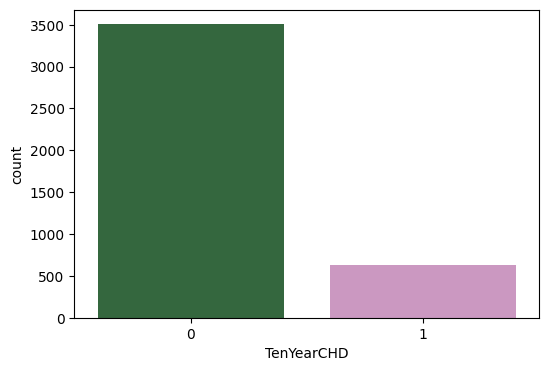

In [6]:
# counting no of patiets affected with CHD 

plt.figure(figsize=(6,4))
sns.countplot(x='TenYearCHD', data = disease_df, palette='cubehelix')
plt.show()

### Counting number of patients affected by CHD where (0= Not Affected; 1= Affected)

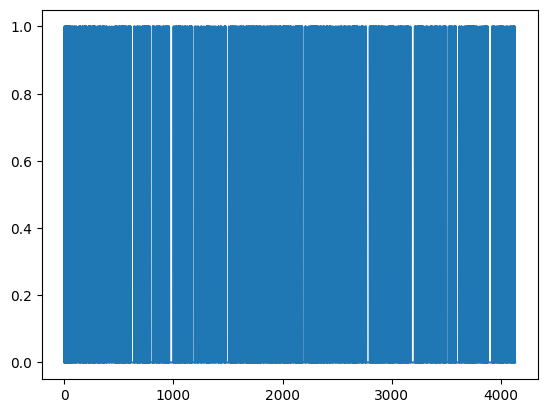

In [7]:
laste = disease_df['TenYearCHD'].plot()
plt.show(laste)

## Fitting Logistic Regression Model for Heart Disease Prediction

In [8]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

## Evaluating Logistic Regression Model

In [9]:
# Evaluation and accuracy
from sklearn.metrics import accuracy_score

print(f'Accuracy of the model is = {accuracy_score(y_test, y_pred)}')

Accuracy of the model is = 0.8419354838709677


## Confusion Matrix

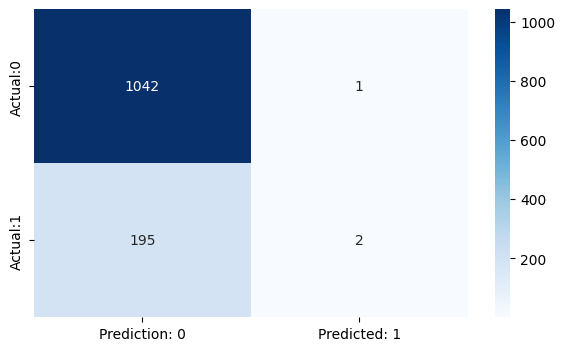

The details of the confusion matrix =
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1043
           1       0.67      0.01      0.02       197

    accuracy                           0.84      1240
   macro avg       0.75      0.50      0.47      1240
weighted avg       0.81      0.84      0.77      1240



In [10]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
conf_matrix = pd.DataFrame(data = cm, 
                          columns = ['Prediction: 0', 'Predicted: 1'],
                          index = ['Actual:0', 'Actual:1'])

plt.figure(figsize=(7,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap = 'Blues')

plt.show()
print('The details of the confusion matrix =')
print(classification_report(y_test, y_pred))